# 02 · Modelling: baseline vs advanced
### Predicting repeat-loan probability

**Design choices, and why**

| Choice | Reason |
|---|---|
| **Out-of-time test** (train 2022–23, test 2024) | Mirrors deployment: the model is always scored on future customers |
| **GroupKFold by `customer_id`** for tuning | The same ID never sits in both training and validation folds, which prevents leakage |
| **Baseline: WoE logistic scorecard** | Industry standard in credit; transparent and easy to explain to Risk/Policy and regulators |
| **Advanced: LightGBM** with random-search tuning | Captures non-linearities and interactions the scorecard can't |
| **Gender excluded** | Fair-lending practice; kept only for bias checks |
| **Metrics:** AUC/Gini, KS, PR-AUC, Brier, lift | Ranking quality *and* calibration, against explicit random baselines |

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

from src.config import *
from src import plots as P
P.set_style()
pd.set_option("display.float_format", "{:,.4f}".format)
pd.set_option("display.max_columns", 30)

import joblib
from sklearn.inspection import permutation_importance
from src.features import model_matrix
from src import modelling as Mo, evaluation as E

f = pd.read_pickle(PROCESSED_DIR / "features.pkl")
train, test = Mo.oot_split(f)
X_tr, X_te = model_matrix(train), model_matrix(test)
y_tr, y_te = train[TARGET].values, test[TARGET].values
print(f"Train: {len(train):,} rows (2022–23), repeat rate {y_tr.mean():.1%}")
print(f"Test : {len(test):,} rows (2024),    repeat rate {y_te.mean():.1%}")
print(f"Features: {X_tr.shape[1]}  ({len(NUMERIC_FEATURES)} numeric, {len(FLAG_FEATURES)} flags, {len(CATEGORICAL_FEATURES)} categorical)")

Train: 66,780 rows (2022–23), repeat rate 30.0%
Test : 33,220 rows (2024),    repeat rate 30.2%
Features: 26  (12 numeric, 8 flags, 6 categorical)


## 1. Baseline: WoE logistic regression scorecard

In [2]:
woe = Mo.WoELogit(n_bins=10, C=1.0).fit(X_tr, y_tr)
p_woe = woe.predict_proba(X_te)[:, 1]
cv_woe, _ = Mo.grouped_cv_auc(Mo.WoELogit(), X_tr, y_tr, train[ID_COL])
print(f"Grouped 5-fold CV AUC (train): {cv_woe:.4f}")
print(f"Out-of-time AUC (2024):        {E.score_metrics(y_te, p_woe)['AUC']:.4f}")
woe.coefficients().head(10).to_frame("coefficient on WoE")

Grouped 5-fold CV AUC (train): 0.4994
Out-of-time AUC (2024):        0.5021


,coefficient on WoE
app_month,1.0831
nb_txn_cnt,1.0462
income_clean,0.9695
loan_to_income,0.9575
age,0.9286
city_clean,0.9093
credit_score,0.8314
loan_amount,0.7643
tenure_days,0.7112
days_since_last_txn_credit_repayment_24month,0.6961


## 2. Advanced: LightGBM, tuned with customer-grouped CV

In [3]:
best, search = Mo.tune_lgbm(X_tr, y_tr, train[ID_COL], n_iter=12)
search.head(6).style.format({"cv_auc": "{:.4f}"})

,num_leaves,learning_rate,n_estimators,min_child_samples,subsample,colsample_bytree,reg_lambda,cv_auc
0,31,0.010000,800,300,1.000000,1.000000,1.000000,0.5052
1,7,0.100000,800,100,0.850000,0.600000,20.000000,0.5048
2,7,0.100000,400,100,0.850000,1.000000,0.000000,0.5043
3,31,0.030000,400,50,0.700000,0.800000,20.000000,0.5042
4,63,0.100000,200,100,0.850000,0.800000,0.000000,0.5038
5,31,0.030000,200,1000,0.850000,1.000000,5.000000,0.5028


In [4]:
lgbm = Mo.make_lgbm(**best).fit(X_tr, y_tr)
p_lgbm = lgbm.predict_proba(X_te)[:, 1]
print("Best params:", best)
print(f"Best grouped CV AUC: {search.cv_auc.iloc[0]:.4f}   |   Out-of-time AUC: {E.score_metrics(y_te, p_lgbm)['AUC']:.4f}")

Best params: {'num_leaves': 31, 'learning_rate': 0.01, 'n_estimators': 800, 'min_child_samples': 300, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_lambda': 1.0}
Best grouped CV AUC: 0.5052   |   Out-of-time AUC: 0.5027


## 3. Head-to-head on the 2024 out-of-time sample

In [5]:
p_const = np.full(len(y_te), y_tr.mean())
rows = [E.score_metrics(y_te, p_const, "Constant 30% (no model)"),
        E.score_metrics(y_te, p_woe, "Baseline: WoE logistic"),
        E.score_metrics(y_te, p_lgbm, "Advanced: LightGBM")]
for r, p in zip(rows, [None, p_woe, p_lgbm]):
    r["AUC_95%_CI"] = "–" if p is None else "{:.3f} – {:.3f}".format(*E.bootstrap_auc_ci(y_te, p))
results = pd.DataFrame(rows).set_index("model")
results[["AUC", "AUC_95%_CI", "Gini", "KS", "PR_AUC", "PR_AUC_random", "Brier", "Brier_base_rate", "LogLoss"]].style.format(
    {c: "{:.4f}" for c in ["AUC", "Gini", "KS", "PR_AUC", "PR_AUC_random", "Brier", "Brier_base_rate", "LogLoss"]})

,AUC,AUC_95%_CI,Gini,KS,PR_AUC,PR_AUC_random,Brier,Brier_base_rate,LogLoss
model,,,,,,,,,
Constant 30% (no model),0.5000,–,0.0000,0.0000,0.3015,0.3015,0.2106,0.2106,0.6121
Baseline: WoE logistic,0.5021,0.496 – 0.509,0.0042,0.0070,0.3051,0.3015,0.2108,0.2106,0.6127
Advanced: LightGBM,0.5027,0.496 – 0.510,0.0054,0.0130,0.3016,0.3015,0.2114,0.2106,0.6141


**Reading the table**

* **AUC ≈ 0.50 and Gini ≈ 0 for both models.** That's coin-flip ranking, and the 95% confidence intervals include 0.50.
* **PR-AUC equals the base rate (0.30)**, which is exactly what random scores give.
* **The Brier score is no better (LightGBM is slightly worse) than predicting 30% for everyone.** The advanced model adds variance without adding information, the textbook symptom of fitting noise.

## 4. Formal test: is either model better than random?

**Label-permutation test:** shuffle the 2024 outcomes 1,000 times and recompute AUC against the same scores. If the model had learned anything real, its AUC would sit far to the right of this "pure chance" distribution.

WoE logistic : AUC 0.5021, permutation p-value 0.285
LightGBM     : AUC 0.5027, permutation p-value 0.223


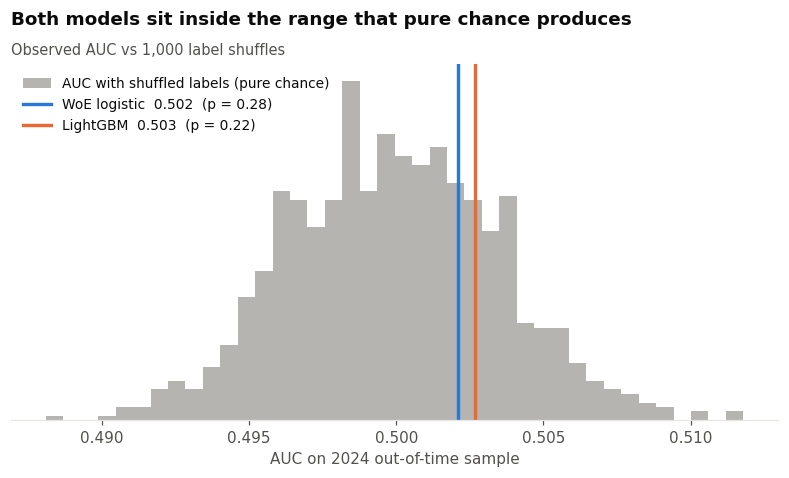

In [6]:
obs_w, null_w, pv_w = E.label_permutation_test(y_te, p_woe, n_perm=1000)
obs_l, null_l, pv_l = E.label_permutation_test(y_te, p_lgbm, n_perm=1000, seed=1)
print(f"WoE logistic : AUC {obs_w:.4f}, permutation p-value {pv_w:.3f}")
print(f"LightGBM     : AUC {obs_l:.4f}, permutation p-value {pv_l:.3f}")
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(null_l, bins=40, color=P.GREY, alpha=0.8, label="AUC with shuffled labels (pure chance)")
ax.axvline(obs_w, color=P.BLUE, lw=2.2, label=f"WoE logistic  {obs_w:.3f}  (p = {pv_w:.2f})")
ax.axvline(obs_l, color=P.ORANGE, lw=2.2, label=f"LightGBM  {obs_l:.3f}  (p = {pv_l:.2f})")
ax.legend(loc="upper left", fontsize=9); ax.set_xlabel("AUC on 2024 out-of-time sample"); ax.set_yticks([])
ax.set_title("Both models sit inside the range that pure chance produces", pad=26)
P.subtitle(ax, "Observed AUC vs 1,000 label shuffles")
P.save(fig, "fig06_permutation_test"); plt.show()

## 5. ROC and gains: what targeting would look like

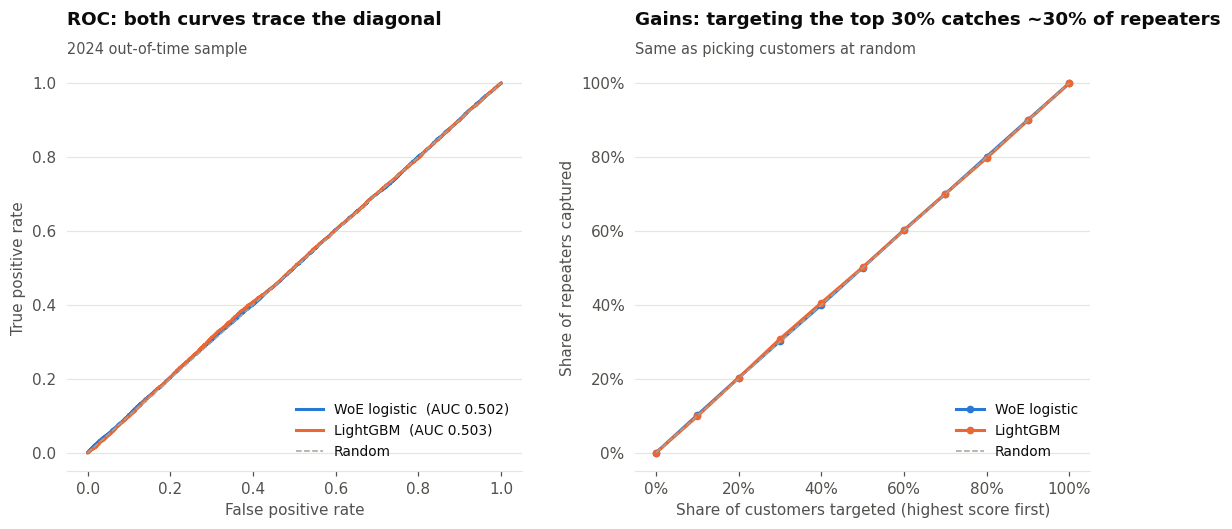

decile,n,repeaters,avg_score,repeat_rate,lift,cum_capture,cum_population
1,3322,990,0.346,29.8%,0.99,9.9%,10%
2,3322,1040,0.323,31.3%,1.04,20.3%,20%
3,3322,1056,0.312,31.8%,1.05,30.8%,30%
4,3322,978,0.304,29.4%,0.98,40.6%,40%
5,3322,962,0.297,29.0%,0.96,50.2%,50%
6,3322,1002,0.290,30.2%,1.00,60.2%,60%
7,3322,990,0.283,29.8%,0.99,70.1%,70%
8,3322,969,0.275,29.2%,0.97,79.7%,80%
9,3322,1023,0.266,30.8%,1.02,90.0%,90%
10,3322,1006,0.246,30.3%,1.00,100.0%,100%


In [7]:
from sklearn.metrics import roc_curve
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"wspace": 0.25})
for name, p, c in [("WoE logistic", p_woe, P.BLUE), ("LightGBM", p_lgbm, P.ORANGE)]:
    fpr, tpr, _ = roc_curve(y_te, p)
    a1.plot(fpr, tpr, color=c, lw=2, label=f"{name}  (AUC {E.score_metrics(y_te, p)['AUC']:.3f})")
    g = E.gains_table(y_te, p)
    a2.plot([0] + list(g.cum_population), [0] + list(g.cum_capture), color=c, lw=2, marker="o", ms=4, label=name)
a1.plot([0, 1], [0, 1], color=P.GREY, ls="--", lw=1, label="Random")
a2.plot([0, 1], [0, 1], color=P.GREY, ls="--", lw=1, label="Random")
a1.set_xlabel("False positive rate"); a1.set_ylabel("True positive rate"); a1.legend(loc="lower right", fontsize=9)
a1.set_title("ROC: both curves trace the diagonal", pad=26); P.subtitle(a1, "2024 out-of-time sample")
P.pct_axis(a2); P.pct_axis(a2, "x"); a2.set_xlabel("Share of customers targeted (highest score first)")
a2.set_ylabel("Share of repeaters captured"); a2.legend(loc="lower right", fontsize=9)
a2.set_title("Gains: targeting the top 30% catches ~30% of repeaters", pad=26)
P.subtitle(a2, "Same as picking customers at random")
P.save(fig, "fig05_roc_gains"); plt.show()
E.gains_table(y_te, p_lgbm).style.format({"avg_score": "{:.3f}", "repeat_rate": "{:.1%}", "lift": "{:.2f}",
                                         "cum_capture": "{:.1%}", "cum_population": "{:.0%}"}).hide(axis="index")

## 6. Key drivers, and why we shouldn't believe the usual importance chart

Gain-based importance and SHAP *always* rank features, even when the model learned only noise. Two safeguards:

1. **A random-noise feature** is added to the model. Any "driver" that doesn't beat pure noise isn't a driver.
2. **Permutation importance on the 2024 test set:** how much AUC actually drops when a feature is scrambled. A real driver drops it clearly above zero.

In [8]:
import shap
rng = np.random.default_rng(7)
X_tr_n, X_te_n = X_tr.copy(), X_te.copy()
X_tr_n["RANDOM_NOISE"] = rng.normal(size=len(X_tr_n)); X_te_n["RANDOM_NOISE"] = rng.normal(size=len(X_te_n))
lgbm_n = Mo.make_lgbm(**best).fit(X_tr_n, y_tr)

sample = X_te_n.sample(5000, random_state=0)
sv = shap.TreeExplainer(lgbm_n).shap_values(sample)
sv = sv[1] if isinstance(sv, list) else sv
shap_imp = pd.Series(np.abs(sv).mean(0), index=sample.columns).sort_values(ascending=False)

perm = permutation_importance(lgbm_n, X_te_n, y_te, scoring="roc_auc", n_repeats=5, random_state=0)
perm_imp = pd.DataFrame({"auc_drop_mean": perm.importances_mean, "auc_drop_std": perm.importances_std},
                        index=X_te_n.columns).sort_values("auc_drop_mean", ascending=False)
print(f"RANDOM_NOISE ranks #{list(shap_imp.index).index('RANDOM_NOISE') + 1} of {len(shap_imp)} by mean |SHAP|")
print(f"Largest AUC drop from scrambling any feature: {perm_imp.auc_drop_mean.max():.4f}")

RANDOM_NOISE ranks #14 of 27 by mean |SHAP|
Largest AUC drop from scrambling any feature: 0.0023


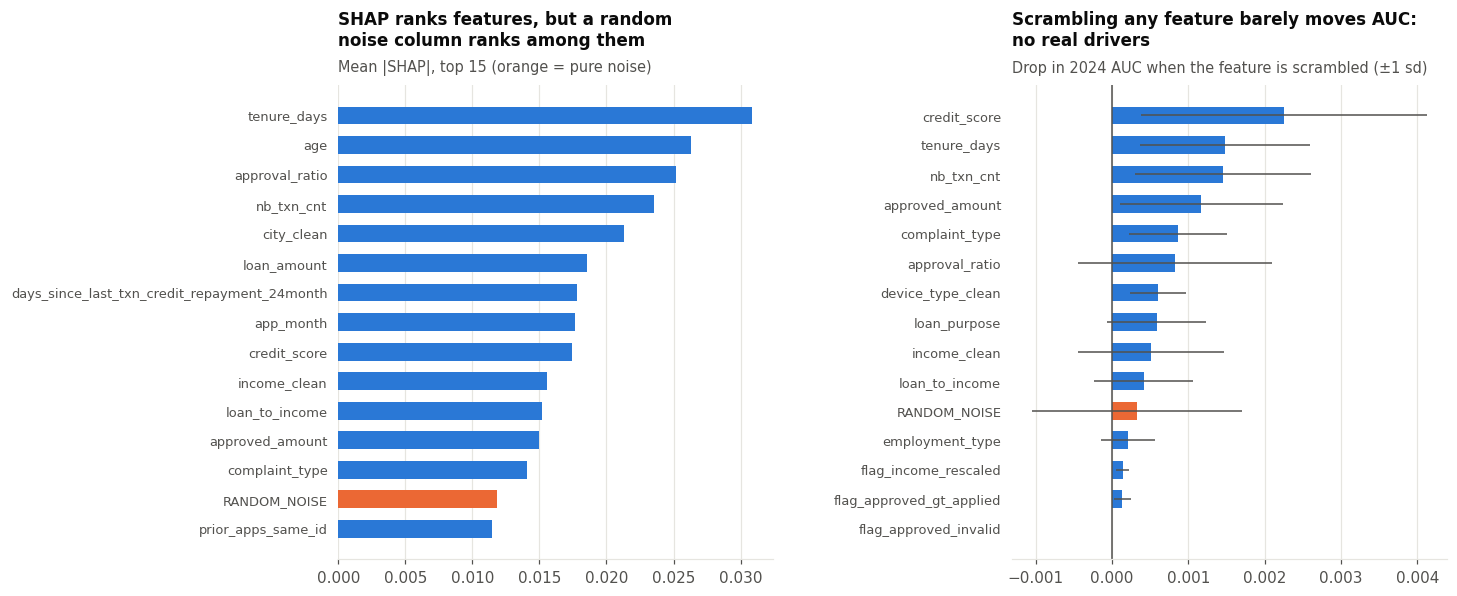

In [9]:
top = shap_imp.head(15)[::-1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw={"wspace": 0.55})
a1.barh(top.index, top.values, color=[P.ORANGE if i == "RANDOM_NOISE" else P.BLUE for i in top.index], height=0.6)
a1.grid(axis="x", color=P.GRID); a1.grid(axis="y", visible=False); a1.tick_params(axis="y", labelsize=8.5)
a1.set_title("SHAP ranks features, but a random\nnoise column ranks among them", pad=26, fontsize=11)
P.subtitle(a1, "Mean |SHAP|, top 15 (orange = pure noise)")
pi = perm_imp.head(15)[::-1]
a2.barh(pi.index, pi.auc_drop_mean, xerr=pi.auc_drop_std, color=[P.ORANGE if i == "RANDOM_NOISE" else P.BLUE for i in pi.index],
        height=0.6, error_kw={"ecolor": P.INK_2, "lw": 1})
a2.axvline(0, color=P.INK_2, lw=1)
a2.grid(axis="x", color=P.GRID); a2.grid(axis="y", visible=False); a2.tick_params(axis="y", labelsize=8.5)
a2.set_title("Scrambling any feature barely moves AUC:\nno real drivers", pad=26, fontsize=11)
P.subtitle(a2, "Drop in 2024 AUC when the feature is scrambled (±1 sd)")
P.save(fig, "fig08_drivers_vs_noise"); plt.show()

**Conclusion on drivers:** no feature stands clearly apart from a column of pure random noise. Scrambling the "top" feature lowers AUC by only about 0.002, and the error bars overlap the noise column's. The SHAP ranking is the model memorising noise. Presenting "credit score is the #1 driver" from this model would be misleading, so we don't.

What *should* drive repeat borrowing (to test once a valid label exists): repayment track record on the first loan, days since loan closure, whether we made a pre-approved offer, product type, app engagement, and service experience (complaints).

## 7. Positive control: would this pipeline find signal if it existed?

A fair challenge: *"maybe your pipeline is broken."* To check, we generate labels with a known, realistic relationship to the features (higher credit score, more transactions, recent repayment, longer tenure and no complaint all make repeat borrowing more likely) at increasing strength. Then we run the **exact same** split, models and metrics.

In [10]:
rows = []
for s in [0.0, 0.15, 0.3, 0.5, 0.8, 1.2]:
    ys = Mo.synthetic_labels(f, s)
    ytr_s, yte_s = ys[train.index], ys[test.index]
    w = Mo.WoELogit().fit(X_tr, ytr_s)
    l = Mo.make_lgbm(**best).fit(X_tr, ytr_s)
    rows.append({"signal_strength": s, "repeat_rate": ys.mean(),
                 "WoE logistic AUC": E.score_metrics(yte_s, w.predict_proba(X_te)[:, 1])["AUC"],
                 "LightGBM AUC": E.score_metrics(yte_s, l.predict_proba(X_te)[:, 1])["AUC"]})
pc = pd.DataFrame(rows)
pc.style.format({"repeat_rate": "{:.1%}", "WoE logistic AUC": "{:.3f}", "LightGBM AUC": "{:.3f}"}).hide(axis="index")

signal_strength,repeat_rate,WoE logistic AUC,LightGBM AUC
0.000000,29.9%,0.503,0.498
0.150000,30.0%,0.541,0.530
0.300000,29.9%,0.588,0.581
0.500000,29.9%,0.647,0.644
0.800000,29.9%,0.724,0.721
1.200000,29.8%,0.794,0.793


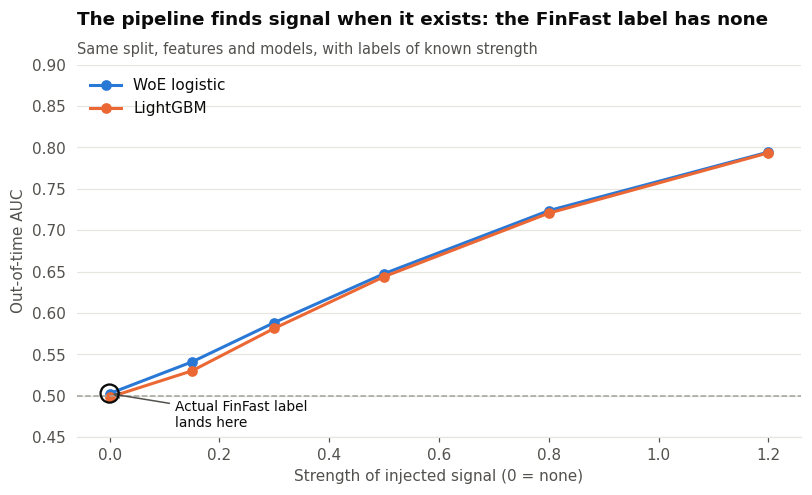

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(pc.signal_strength, pc["WoE logistic AUC"], marker="o", color=P.BLUE, lw=2, label="WoE logistic")
ax.plot(pc.signal_strength, pc["LightGBM AUC"], marker="o", color=P.ORANGE, lw=2, label="LightGBM")
ax.axhline(0.5, color=P.GREY, ls="--", lw=1)
ax.scatter([0], [results.loc["Advanced: LightGBM", "AUC"]], s=140, facecolors="none", edgecolors=P.INK, lw=1.5, zorder=4)
ax.annotate("Actual FinFast label\nlands here", (0, results.loc["Advanced: LightGBM", "AUC"]), xytext=(0.12, 0.462),
            fontsize=9, arrowprops={"arrowstyle": "->", "color": P.INK_2})
ax.set_xlabel("Strength of injected signal (0 = none)"); ax.set_ylabel("Out-of-time AUC"); ax.legend(loc="upper left")
ax.set_ylim(0.45, 0.9)
ax.set_title("The pipeline finds signal when it exists: the FinFast label has none", pad=26)
P.subtitle(ax, "Same split, features and models, with labels of known strength")
P.save(fig, "fig09_positive_control"); plt.show()

## 8. Robustness: other reasonable set-ups give the same answer

In [12]:
from sklearn.model_selection import train_test_split
checks = []
# (a) application-time model: drop post-decision field approved_amount and its ratio
cols_app = [c for c in NUMERIC_FEATURES if c not in ("approved_amount", "approval_ratio")]
Xa_tr, Xa_te = model_matrix(train, numeric=cols_app), model_matrix(test, numeric=cols_app)
checks.append(("Application-time features only", E.score_metrics(y_te, Mo.make_lgbm(**best).fit(Xa_tr, y_tr).predict_proba(Xa_te)[:, 1])["AUC"]))
# (b) class-weighted LightGBM for imbalance
checks.append(("LightGBM, class_weight='balanced'", E.score_metrics(y_te, Mo.make_lgbm(**best, class_weight="balanced").fit(X_tr, y_tr).predict_proba(X_te)[:, 1])["AUC"]))
# (c) random (not out-of-time) split
X_all, y_all = model_matrix(f), f[TARGET].values
a, b, ya, yb = train_test_split(X_all, y_all, test_size=0.3, random_state=SEED, stratify=y_all)
checks.append(("Random 70/30 split", E.score_metrics(yb, Mo.make_lgbm(**best).fit(a, ya).predict_proba(b)[:, 1])["AUC"]))
# (d) only raw columns, no cleaning-derived features
raw_num = ["age", "income_clean", "credit_score", "loan_amount", "approved_amount", "nb_txn_cnt",
           "days_since_last_txn_credit_repayment_24month"]
Xr_tr, Xr_te = model_matrix(train, numeric=raw_num, flags=[]), model_matrix(test, numeric=raw_num, flags=[])
checks.append(("Raw columns only", E.score_metrics(y_te, Mo.make_lgbm(**best).fit(Xr_tr, y_tr).predict_proba(Xr_te)[:, 1])["AUC"]))
pd.DataFrame(checks, columns=["variant", "AUC"]).style.format({"AUC": "{:.4f}"}).hide(axis="index")

variant,AUC
Application-time features only,0.5036
"LightGBM, class_weight='balanced'",0.5040
Random 70/30 split,0.5029
Raw columns only,0.5040


## 9. Save models, scores and metrics

In [13]:
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(woe, MODEL_DIR / "baseline_woe_logit.joblib")
joblib.dump(lgbm, MODEL_DIR / "lightgbm.joblib")
pd.DataFrame({ID_COL: test[ID_COL].values, "application_date": test.application_date.values, TARGET: y_te,
              "score_woe": p_woe, "score_lgbm": p_lgbm}).to_csv(PROCESSED_DIR / "oot_scores.csv", index=False)
metrics = {"oot": results.drop(columns="AUC_95%_CI").to_dict(orient="index"),
           "permutation_p_value": {"woe": pv_w, "lgbm": pv_l},
           "lgbm_best_params": best, "lgbm_cv_auc": float(search.cv_auc.iloc[0]),
           "positive_control": pc.to_dict(orient="records")}
(MODEL_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, default=float))
print("saved models/, metrics.json and oot_scores.csv")

saved models/, metrics.json and oot_scores.csv


## Modelling verdict

| Question | Answer |
|---|---|
| Does the advanced model beat the baseline? | **No.** Both have AUC ≈ 0.50 out-of-time. LightGBM is slightly *worse* on calibration (Brier) because it fits noise. |
| Does either beat random? | **No.** Permutation p-values are far above 0.05; the AUC confidence intervals include 0.50. |
| Is the pipeline at fault? | **No.** The same pipeline's AUC rises steadily from 0.54 to 0.79 as real signal is injected into the labels (positive control). |
| Deploy? | **No.** A model that ranks at random would send retention spend to the wrong customers while looking "data-driven". |

**Recommendation:** treat this as a *data* problem, not a *modelling* problem. Validate the `repeat_loan` definition and its join keys with the data owner, then retrain. The pipeline here (cleaning, grouped CV, out-of-time test, permutation test, monitoring) can be reused unchanged. Notebook 03 converts this into business actions.